# 1. 데이터 로드 및 구조 확인

이번 단계에서는 Semantic Segmentation 학습을 위해 이미지와 마스크 데이터를 불러오는 과정을 수행한다.  
Segmentation 문제에서는 일반적인 이미지 분류와 달리, 입력 이미지와 동일한 크기의 마스크(label image)가 필요하다.

각 마스크의 픽셀 값은 클래스 번호를 의미하며, 본 과제에서는 총 11개 클래스를 예측해야 한다.  
즉, 모델은 각 픽셀마다 0~10 사이의 클래스 중 하나를 분류하게 된다.

이 단계에서 수행할 작업은 다음과 같다.

1. 데이터 경로 설정
2. 이미지와 마스크 파일 목록 불러오기
3. 이미지-마스크 파일이 올바르게 매칭되는지 확인
4. 샘플 데이터 시각화를 통해 데이터가 정상적으로 로드되는지 점검
5. PyTorch Dataset / DataLoader 형태로 구성할 준비

이 과정은 이후 전처리, 모델 학습, 성능 평가의 기반이 되므로 매우 중요하다.

In [1]:
import os
import torch
import torch.nn as nn
import random
from glob import glob

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
# 드라이브에 업로드한 경우
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile
import os

# 드라이브 마운트경우 드라이브 경로로
zip_filename = '/content/drive/MyDrive/dataset/football_new.zip'

# 압축 해제는 현재 경로로 설정
extract_folder = './football_new'

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zipf:
    zipf.extractall(extract_folder)

### json 읽기

In [4]:
import json

json_path = "/content/football_new/COCO_Football Pixel.json"
with open(json_path,"r",encoding='utf-8') as f:
  coco_data = json.load(f)

print(coco_data.keys())
print("images 개수:",len(coco_data["images"]))
print("annotations 개수",len(coco_data["annotations"]))
print("categories 개수",len(coco_data["categories"]))

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
images 개수: 100
annotations 개수 915
categories 개수 11


### annotation 묶기 + cateegory 매핑

In [5]:
from collections import defaultdict
coco_images = coco_data["images"]
annotations = coco_data["annotations"]
categories = coco_data["categories"]

print("image 개수:",len(coco_images))
print("annotation 개수:",len(annotations))
print("category 개수:", len(categories))

ann_dict = defaultdict(list)
for ann in annotations:
  ann_dict[ann["image_id"]].append(ann)

category_id_to_idx = {}
idx_to_category_name = {}

for idx, cat in enumerate(categories, start=1):
  category_id_to_idx[cat["id"]] = idx
  idx_to_category_name[idx] = cat["name"]

print("category_id_to_idx:", category_id_to_idx)
print("idx_to_category_name:", idx_to_category_name)

image 개수: 100
annotation 개수: 915
category 개수: 11
category_id_to_idx: {1393250: 1, 1392807: 2, 1392806: 3, 1392805: 4, 1392804: 5, 1392803: 6, 1392802: 7, 1392801: 8, 1392800: 9, 1392799: 10, 1392794: 11}
idx_to_category_name: {1: 'Goal Bar', 2: 'Referee', 3: 'Advertisements', 4: 'Ground', 5: 'Ball', 6: 'Coaches & Officials', 7: 'Audience', 8: 'Goalkeeper B', 9: 'Goalkeeper A', 10: 'Team B', 11: 'Team A'}


### 이미지 폴더 확인

In [6]:
image_root = "/content/football_new/images"
for root,dirs,files in os.walk(image_root):
  print(root,files[:5])

/content/football_new/images ['Frame 1  (33).jpg___save.png', 'Frame 1  (31).jpg___save.png', 'Frame 1  (23).jpg___fuse.png', 'Frame 1  (46).jpg___fuse.png', 'Frame 1  (78).jpg___fuse.png']


### mask 저장 폴더 만들기

In [7]:
import glob

mask_dir = "football_new/masks"
os.makedirs(mask_dir, exist_ok=True)

for i in glob.glob(os.path.join(mask_dir,"*.png")):
  os.remove(f)

print("기존 mask 삭제 완료")

기존 mask 삭제 완료


### 1장 테스트

In [8]:
import cv2

img_info = coco_images[0]

img_id = img_info["id"]
file_name = img_info["file_name"]
height = img_info["height"]
width = img_info["width"]

image_dir = "/content/football_new/images"
img_path = os.path.join(image_dir, file_name)

mask = np.zeros((height, width), dtype=np.uint8)
anns = ann_dict[img_id]

print("img_id:",img_id)
print("file_name:", file_name)
print("실제 img_path:",img_path)
print("ann 개수:", len(anns))

for ann in anns:
  category_id = ann["category_id"]
  class_idx = category_id_to_idx[category_id]
  segmentation = ann["segmentation"]

  if not isinstance(segmentation, list):
    continue

  for seg in segmentation:
    if len(seg) < 6:
      continue

    pts = np.array(seg,dtype=np.float32).reshape(-1,2)
    pts = np.round(pts).astype(np.int32).reshape((-1,1,2))
    cv2.fillPoly(mask, [pts], color=class_idx)

print("unique(mask):", np.unique(mask))

img_id: 1
file_name: Frame 1  (14).jpg
실제 img_path: /content/football_new/images/Frame 1  (14).jpg
ann 개수: 10
unique(mask): [ 1  3  7  8 10 11]


### 테스트 mask 시각화

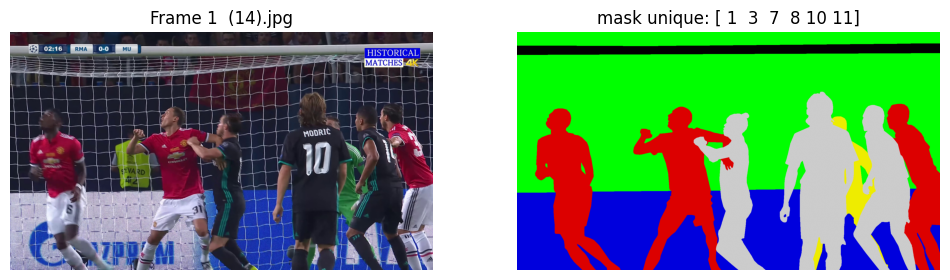

In [9]:
img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title(file_name)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask,cmap="nipy_spectral")
plt.title(f"mask unique: {np.unique(mask)}")
plt.axis("off")

plt.show()

### 전체 mask 생성

In [10]:
mask_dir = "/content/football_new/masks"
os.makedirs(mask_dir,exist_ok=True)

for f in glob.glob(os.path.join(mask_dir, "*.png")):
  os.remove(f)

print("기존 mask 삭제 완료")

for img_info in coco_images:
  img_id = img_info["id"]
  file_name = img_info["file_name"]
  height = img_info["height"]
  width = img_info["width"]

  mask = np.zeros((height, width), dtype=np.uint8)
  anns = ann_dict[img_id]

  for ann in anns:
    category_id = ann["category_id"]
    class_idx = category_id_to_idx[category_id]
    segmentation = ann["segmentation"]

    if not isinstance(segmentation, list):
      continue

    for seg in segmentation:
      if len(seg) < 6:
        continue

      pts = np.array(seg,dtype=np.float32).reshape(-1,2)
      pts = np.round(pts).astype(np.int32).reshape((-1,1,2))
      cv2.fillPoly(mask, [pts], color=class_idx)

  save_path = os.path.join(mask_dir, file_name.replace(".jpg",".png"))
  Image.fromarray(mask).save(save_path)

print("전체 mask 생성 완료")

기존 mask 삭제 완료
전체 mask 생성 완료


### 전체 mask 검증

In [11]:
all_classes = set()

for img_info in coco_images:
  mask_path = os.path.join(mask_dir, img_info["file_name"].replace(".jpg",".png"))
  mask = np.array(Image.open(mask_path))
  all_classes.update(np.unique(mask).tolist())

print("전체 mask에서 나온 클래스:",sorted(all_classes))

전체 mask에서 나온 클래스: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11]


### Dataset 클래스(핵심)

In [12]:
class FootballDataset(Dataset):
  def __init__(self, coco_images, image_dir, mask_dir, transform = None):
    self.images = coco_images
    self.image_dir = image_dir
    self.mask_dir = mask_dir
    self.transform = transform

  def __len__(self):
    return len(self.images)

  def __getitem__(self,idx):
    img_info = self.images[idx]
    file_name = img_info["file_name"]

    img_path = os.path.join(self.image_dir, file_name)
    mask_path = os.path.join(self.mask_dir,file_name.replace(".jpg",".png"))

    image = Image.open(img_path).convert("RGB")
    image = np.array(image)

    mask = np.array(Image.open(mask_path))

    if self.transform:
      augmented = self.transform(image=image, mask = mask)
      image = augmented["image"]
      mask = augmented["mask"]

    image = torch.tensor(image, dtype = torch.float32).permute(2,0,1) /255.0
    mask = torch.tensor(mask, dtype = torch.long)

    return image,mask

### DataLoader

In [13]:
image_dir = "/content/football_new/images"
mask_dir = "/content/football_new/masks"

dataset = FootballDataset(
    coco_images, image_dir, mask_dir
)

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print(len(dataset))

100


### 데이터 확인

In [14]:
images, masks = next(iter(loader))

print("image shape:",images.shape)
print("mask shape:",masks.shape)
print("mask unique:",torch.unique(masks))

image shape: torch.Size([4, 3, 1080, 1920])
mask shape: torch.Size([4, 1080, 1920])
mask unique: tensor([ 0,  1,  3,  4,  7,  8,  9, 10, 11])


### transform 추가

In [15]:
import albumentations as A #<- segmentation에서는 이미지 + 마스크 동시 변환 되는걸 쓰는게 좋음

train_transform = A.Compose([
    A.Resize(224,384)
])

val_transform = A.Compose([
    A.Resize(224,384)
])

### train/val 분리

In [16]:
from sklearn.model_selection import train_test_split

train_images, val_images = train_test_split(
    coco_images,
    test_size = 0.2,
    random_state = 42
)

print("train:",len(train_images))
print("val:",len(val_images))

train: 80
val: 20


### Dataset/DataLoader

In [17]:
train_dataset = FootballDataset(
    coco_images = train_images,
    image_dir = image_dir,
    mask_dir = mask_dir,
    transform = train_transform
)

val_dataset = FootballDataset(
    coco_images = val_images,
    image_dir = image_dir,
    mask_dir = mask_dir,
    transform = val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 4,
    shuffle = True,
    num_workers = 0
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 4,
    shuffle = False,
    num_workers = 0
)

### U-Net 모델

In [18]:
class DoubleConv(nn.Module):
  def __init__(self,in_ch,out_ch):
    super().__init__()
    self.block = nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3,padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace = True),
        nn.Conv2d(out_ch,out_ch, kernel_size=3,padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True)
    )

  def forward(self,x):
    return self.block(x)

class UNet(nn.Module):
  def __init__(self,in_channels=3, num_classes =12):
    super().__init__()
    #Encoder
    self.enc1 = DoubleConv(in_channels,64)  #3,64,384,640
    self.pool1 = nn.MaxPool2d(2)            #3,64,192,320

    self.enc2 = DoubleConv(64,128)          #64,128,192,320
    self.pool2 = nn.MaxPool2d(2)            #64,128,96,160

    self.enc3 = DoubleConv(128,256)         #128,256,96,160
    self.pool3 = nn.MaxPool2d(2)            #128,256,48,80

    self.enc4 = DoubleConv(256,512)         #256,512,48,80
    self.pool4 = nn.MaxPool2d(2)            #256,512,24,40

    #bottleneck
    self.bottleneck = DoubleConv(512,1024)

    #Decoder
    self.up4 = nn.ConvTranspose2d(1024,512, kernel_size=2, stride=2)
    self.dec4 = DoubleConv(1024,512)

    self.up3 = nn.ConvTranspose2d(512,256, kernel_size=2, stride=2)
    self.dec3 = DoubleConv(512,256)

    self.up2 = nn.ConvTranspose2d(256,128, kernel_size=2, stride=2)
    self.dec2 = DoubleConv(256,128)

    self.up1 = nn.ConvTranspose2d(128,64, kernel_size=2, stride=2)
    self.dec1 = DoubleConv(128,64)

    #output
    self.out_conv = nn.Conv2d(64,num_classes, kernel_size=1)

  def forward(self,x):
    e1 = self.enc1(x)
    e2 = self.enc2(self.pool1(e1))
    e3 = self.enc3(self.pool2(e2))
    e4 = self.enc4(self.pool3(e3))

    b = self.bottleneck(self.pool4(e4))

    d4 = self.up4(b)
    d4 = torch.cat([d4,e4],dim=1)
    d4  = self.dec4(d4)

    d3 = self.up3(d4)
    d3 = torch.cat([d3,e3],dim=1)
    d3 = self.dec3(d3)

    d2 = self.up2(d3)
    d2 = torch.cat([d2,e2], dim=1)
    d2 = self.dec2(d2)

    d1 = self.up1(d2)
    d1 = torch.cat([d1,e1],dim=1)
    d1 = self.dec1(d1)

    out = self.out_conv(d1)
    return out

### device/model/loss/optimizer

In [52]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:",device)

unet_model = UNet(in_channels=3,num_classes=12).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 1e-4)

Device: cuda


### IoU 계산 함수

In [20]:
def mean_iou(preds, masks, num_classes=12):
  preds = torch.argmax(preds,dim=1)

  ious = []
  for cls in range(num_classes):
    pred_cls = (preds == cls)
    mask_cls = (masks == cls)

    intersection = (pred_cls & mask_cls).sum().item()
    union = (pred_cls | mask_cls).sum().item()

    if union ==0:
      continue

    ious.append(intersection / union)

  if len(ious) ==0:
    return 0.0
  return sum(ious) / len(ious)

### 학습 루프

In [21]:
from tqdm import tqdm

def train_one_epoch(model,loader,criterion,optimizer,device):
  model.train()
  total_loss = 0
  total_iou = 0

  for images,masks in loader:
    images = images.to(device)
    masks = masks.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs,masks)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    total_iou += mean_iou(outputs.detach(),masks)

  return total_loss / len(loader), total_iou / len(loader)

@torch.no_grad()
def val_one_epoch(model,loader,criterion,device):
  model.eval()
  total_loss = 0
  total_iou = 0

  for images,masks in loader:
    images = images.to(device)
    masks = masks.to(device)

    outputs = model(images)
    loss = criterion(outputs,masks)

    total_loss += loss.item()
    total_iou += mean_iou(outputs,masks)

  return total_loss/ len(loader), total_iou/len(loader)

### 학습 실행

In [22]:
num_epochs = 10
train_losses, val_losses = [],[]
train_ious, val_ious = [],[]

for epoch in range(num_epochs):
  train_loss, train_iou = train_one_epoch(model,train_loader,criterion,optimizer,device)
  val_loss, val_iou = val_one_epoch(model,val_loader,criterion,device)

  train_losses.append(train_loss)
  val_losses.append(val_loss)
  train_ious.append(train_iou)
  val_ious.append(val_iou)

  print(f"Epoch {epoch+1}/{num_epochs}")
  print(f"Train Loss:{train_loss:.4f} | Train IoU:{train_iou:.4f}")
  print(f"Val Loss:{val_loss:.4f} | Val IoU:{val_iou:.4f}")

Epoch 1/10
Train Loss:2.1017 | Train IoU:0.1332
Val Loss:2.2784 | Val IoU:0.0373
Epoch 2/10
Train Loss:1.5890 | Train IoU:0.2160
Val Loss:1.4843 | Val IoU:0.1965
Epoch 3/10
Train Loss:1.3623 | Train IoU:0.2715
Val Loss:1.1763 | Val IoU:0.2454
Epoch 4/10
Train Loss:1.2318 | Train IoU:0.3046
Val Loss:1.0964 | Val IoU:0.3272
Epoch 5/10
Train Loss:1.1354 | Train IoU:0.3363
Val Loss:0.9986 | Val IoU:0.3571
Epoch 6/10
Train Loss:1.0482 | Train IoU:0.3491
Val Loss:0.9071 | Val IoU:0.3676
Epoch 7/10
Train Loss:0.9971 | Train IoU:0.3789
Val Loss:0.9605 | Val IoU:0.3838
Epoch 8/10
Train Loss:0.9452 | Train IoU:0.3946
Val Loss:0.9168 | Val IoU:0.3775
Epoch 9/10
Train Loss:0.8460 | Train IoU:0.4302
Val Loss:0.7602 | Val IoU:0.4440
Epoch 10/10
Train Loss:0.7840 | Train IoU:0.4467
Val Loss:0.7071 | Val IoU:0.4770


#### U-Net 성능 개선

In [23]:
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(256,512),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit = 0.1,
        rotate_limit=10,
        p=0.5
    ),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256,512),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [24]:
class FootballDataset(Dataset):
    def __init__(self, coco_images, image_dir, mask_dir, transform=None):
        self.images = coco_images
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        file_name = img_info["file_name"]

        img_path = os.path.join(self.image_dir, file_name)
        mask_path = os.path.join(self.mask_dir, file_name.replace(".jpg", ".png"))

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        #ToTensorV2 쓰면 image는 이미 tensor
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [25]:
import torch.nn.functional as F

class DiceLoss(nn.Module):
  def __init__(self, smooth=1e-6):
    super().__init__()
    self.smooth = smooth

  def forward(self, logits, targets):
    num_classes = logits.shape[1]
    probs = F.softmax(logits,dim=1)

    targets_one_hot = F.one_hot(targets, num_classes=num_classes)
    targets_one_hot = targets_one_hot.permute(0,3,1,2).float()

    dims = [0,2,3]
    intersection = torch.sum(probs * targets_one_hot,dims)
    cardinality = torch.sum(probs + targets_one_hot,dims)

    dice = (2. * intersection + self.smooth) / (cardinality + self.smooth)
    return 1 - dice.mean()

In [26]:
ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss()

def criterion(outputs,masks):
  return 0.5 * ce_loss(outputs, masks) + 0.5 * dice_loss(outputs, masks)

In [27]:
num_epochs = 30
best_val_iou = 0.0

train_losses, val_losses = [],[]
train_ious, val_ious = [],[]

for epoch in range(num_epochs):

  train_loss, train_iou = train_one_epoch(model, train_loader, criterion, optimizer, device)
  val_loss, val_iou = val_one_epoch(model,val_loader,criterion,device)

  train_losses.append(train_loss)
  val_losses.append(val_loss)
  train_ious.append(train_iou)
  val_ious.append(val_iou)

  print(f"\nEpoch {epoch+1}/{num_epochs}")
  print(f"Train Loss:{train_loss:.4f} | Train IoU:{train_iou:.4f}")
  print(f"Val Loss:{val_loss:.4f} | Val IoU:{val_iou:.4f}")

  if val_iou < best_val_iou:
    best_val_iou = val_iou
    torch.save(model.state_dict(),"/content/best_unet.pth")
    print(f"Best Model Saved! IoU:{best_val_iou:.4f}")


Epoch 1/30
Train Loss:0.7774 | Train IoU:0.4275
Val Loss:0.7143 | Val IoU:0.4537

Epoch 2/30
Train Loss:0.7289 | Train IoU:0.4371
Val Loss:0.6949 | Val IoU:0.4748

Epoch 3/30
Train Loss:0.7032 | Train IoU:0.4753
Val Loss:0.6821 | Val IoU:0.4878

Epoch 4/30
Train Loss:0.7248 | Train IoU:0.4694
Val Loss:0.6423 | Val IoU:0.4920

Epoch 5/30
Train Loss:0.6749 | Train IoU:0.5028
Val Loss:0.6501 | Val IoU:0.5126

Epoch 6/30
Train Loss:0.6990 | Train IoU:0.4756
Val Loss:0.6612 | Val IoU:0.5021

Epoch 7/30
Train Loss:0.6643 | Train IoU:0.5169
Val Loss:0.6371 | Val IoU:0.5138

Epoch 8/30
Train Loss:0.6563 | Train IoU:0.5202
Val Loss:0.6096 | Val IoU:0.5410

Epoch 9/30
Train Loss:0.6281 | Train IoU:0.5597
Val Loss:0.5840 | Val IoU:0.5539

Epoch 10/30
Train Loss:0.6117 | Train IoU:0.5633
Val Loss:0.5870 | Val IoU:0.5701

Epoch 11/30
Train Loss:0.5869 | Train IoU:0.5622
Val Loss:0.5675 | Val IoU:0.5735

Epoch 12/30
Train Loss:0.5630 | Train IoU:0.5921
Val Loss:0.5512 | Val IoU:0.5646

Epoch 13/30


### U-Net 예측 시각화

In [44]:
def visualize_unet(model, dataset, device, idx=0):
    model.eval()

    image, mask = dataset[idx]
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)

        print("output type:", type(output))

        if isinstance(output, list):
            output = output[0]
        elif isinstance(output, dict):
            output = output["out"]

        pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    image = image.squeeze(0).cpu().permute(1, 2, 0).numpy()
    mask = mask.numpy()

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="nipy_spectral")
    plt.title("GT Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred, cmap="nipy_spectral")
    plt.title("U-Net Prediction")
    plt.axis("off")

    plt.show()

output type: <class 'torch.Tensor'>


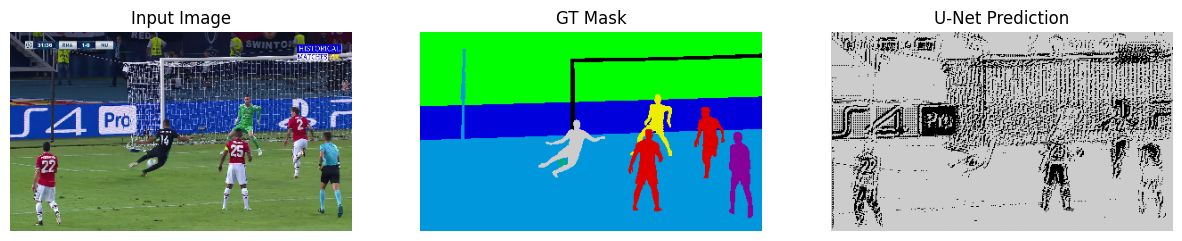

In [54]:
visualize_unet(unet_model, val_dataset, device, idx=0)

### YOLO Seg

In [28]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.2 MB/s eta 0:00:00


### train/val 나누기

In [29]:
train_images, val_images = train_test_split(
    coco_images,
    test_size = 0.2,
    random_state = 42
)

print(len(train_images),len(val_images))

80 20


### 폴더 만들기

In [30]:
base_dir = "/content/football_yolo"

train_img_dir = os.path.join(base_dir,"images/train")
val_img_dir = os.path.join(base_dir,"images/val")
train_lbl_dir = os.path.join(base_dir, "labels/train")
val_lbl_dir = os.path.join(base_dir,"labels/val")

for d in [train_img_dir, val_img_dir, train_lbl_dir, val_lbl_dir]:
  os.makedirs(d, exist_ok=True)

### annotation 묶기

In [31]:
ann_dict = defaultdict(list)
for ann in annotations:
  ann_dict[ann["image_id"]].append(ann)

#### category_id를 YOLO 클래스 번호로 매핑

In [32]:
category_id_to_yolo = {}
yolo_names = []

for idx, cat in enumerate(categories):
  category_id_to_yolo[cat["id"]] = idx
  yolo_names.append(cat["name"])

print(category_id_to_yolo)
print(yolo_names)

{1393250: 0, 1392807: 1, 1392806: 2, 1392805: 3, 1392804: 4, 1392803: 5, 1392802: 6, 1392801: 7, 1392800: 8, 1392799: 9, 1392794: 10}
['Goal Bar', 'Referee', 'Advertisements', 'Ground', 'Ball', 'Coaches & Officials', 'Audience', 'Goalkeeper B', 'Goalkeeper A', 'Team B', 'Team A']


### 이미지 복사 + 라벨 txt 생성

In [33]:
import shutil

def convert_one_split(image_list, out_img_dir, out_lbl_dir, image_dir):
  for img_info in image_list:
    img_id = img_info["id"]
    file_name = img_info["file_name"]
    width = img_info["width"]
    height = img_info["height"]

    src_img = os.path.join(image_dir, file_name)
    dst_img = os.path.join(out_img_dir, file_name)

    shutil.copy(src_img, dst_img)

    label_path = os.path.join(out_lbl_dir, file_name.replace(".jpg",".txt"))

    lines = []
    anns = ann_dict[img_id]

    for ann in anns:
      category_id = ann["category_id"]
      cls_id = category_id_to_yolo[category_id]
      segmentation = ann["segmentation"]

      if not isinstance(segmentation,list):
        continue

      for seg in segmentation:
        if len(seg) < 6:
          continue

        coords = []
        for i in range(0, len(seg),2):
          x = seg[i] / width
          y = seg[i+1] / height
          coords.extend([x,y])

        line = str(cls_id) + " " + " ".join(f"{v:.6f}" for v in coords)
        lines.append(line)

    with open(label_path,"w") as f:
      f.write("\n".join(lines))

In [34]:
image_dir = "/content/football_new/images"

convert_one_split(train_images, train_img_dir, train_lbl_dir, image_dir)
convert_one_split(val_images, val_img_dir, val_lbl_dir, image_dir)

print("YOLO Seg 데이터 변환 완료")

YOLO Seg 데이터 변환 완료


### data.yaml 만들기

In [35]:
yaml_text = f"""
path: {base_dir}
train: images/train
val: images/val

names:
"""

for i,name in enumerate(yolo_names):
  yaml_text += f" {i}: {name}\n"

with open(os.path.join(base_dir, "data.yaml"), "w") as f:
  f.write(yaml_text)

print(yaml_text)


path: /content/football_yolo
train: images/train
val: images/val

names:
 0: Goal Bar
 1: Referee
 2: Advertisements
 3: Ground
 4: Ball
 5: Coaches & Officials
 6: Audience
 7: Goalkeeper B
 8: Goalkeeper A
 9: Team B
 10: Team A



In [36]:
print(os.listdir(train_img_dir)[:5])
print(os.listdir(train_lbl_dir)[:5])

sample_txt = os.path.join(train_lbl_dir, os.listdir(train_lbl_dir)[0])
with open(sample_txt,"r") as f:
  print(f.read()[:500])

['Frame 1  (16).jpg', 'Frame 1  (81).jpg', 'Frame 1  (87).jpg', 'Frame 1  (10).jpg', 'Frame 1  (48).jpg']
['Frame 1  (73).txt', 'Frame 1  (89).txt', 'Frame 1  (25).txt', 'Frame 1  (20).txt', 'Frame 1  (53).txt']
10 0.541146 0.369444 0.540625 0.370370 0.540104 0.370370 0.539583 0.370370 0.539062 0.370370 0.538542 0.370370 0.538021 0.371296 0.537500 0.371296 0.536979 0.371296 0.536458 0.371296 0.535937 0.371296 0.535417 0.372222 0.534896 0.372222 0.534375 0.372222 0.533854 0.373148 0.533333 0.374074 0.532813 0.375000 0.532292 0.375926 0.531771 0.376852 0.531250 0.377778 0.530729 0.378704 0.530208 0.379630 0.529687 0.380556 0.529687 0.381481 0.529167 0.382407 0.528646 0.383333 0.528646 0.384259 0.528125 0.


### 학습

In [51]:
from ultralytics import YOLO

yolo_model = YOLO("yolov8n-seg.pt")

yolo_model.train(
    data = os.path.join(base_dir, "data.yaml"),
    epochs = 50,
    imgsz = 640,
    batch = 8
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7beb860cf350>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,   

### YOLO Seg -> Semantic Mask 변환

In [67]:
def yolo_to_semantic(result, shape):
  H,W = shape
  final_mask = np.zeros((H,W), dtype = np.uint8)

  if result.masks is None:
    return final_mask

  masks = result.masks.data.cpu().numpy()
  classes = result.boxes.cls.cpu().numpy().astype(int)

  for mask, cls in zip(masks, classes):
    mask = (mask > 0.5).astype(np.uint8)

    mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)

    final_mask[mask==1] = cls+1

  return final_mask

### YOLO 시각화

In [78]:
from PIL import Image

def vusualize_yolo(model,dataset, device, idx=0):
  model.eval()

  img_inㄹo = dataset.images[idx]
  file_name = img_info["file_name"]

  img_path = os.path.join(dataset.image_dir,file_name)
  image = np.array(Image.open(img_path).convert("RGB"))

  result = model.predict(img_path,verbose=False)[0]

  #YOLO 결과 이미지
  yolo_vis = result.plot()

  #semantic mask 변환
  yolo_mask = yolo_to_semantic(result, image.shape[:2])

  #GT mask
  mask_path = os.path.join(dataset.mask_dir, file_name.replace(".jpg",".png"))
  gt_mask = np.array(Image.open(mask_path))

  plt.figure(figsize=(18,5))

  plt.subplot(1,4,1)
  plt.imshow(image)
  plt.title("Input Image")
  plt.axis("off")

  plt.subplot(1,4,2)
  plt.imshow(gt_mask, cmap="nipy_spectral")
  plt.title("GT mask")
  plt.axis("off")

  plt.subplot(1,4,3)
  plt.imshow(yolo_vis)
  plt.title("YOLO Detection")
  plt.axis("off")

  plt.subplot(1,4,4)
  plt.imshow(yolo_mask, cmap="nipy_spectral")
  plt.title("YOLO Semantix mask")
  plt.axis("off")

  plt.show()

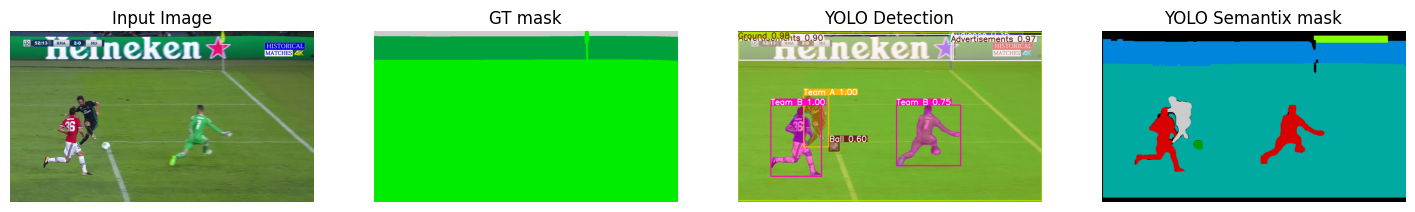

In [79]:
vusualize_yolo(yolo_model,val_dataset, device, idx=0)

### U-Net vs YOLO 한번에 비교

In [84]:
def compare_models(unet_model, yolo_model, dataset, device, idx=0):
  unet_model.eval()

  # dataset 기준 (resize 적용된)
  img_tensor, gt_mask = dataset[idx]
  img_info = dataset.images[idx]
  file_name = img_info["file_name"]

  # image 생성 (이게 핵심)
  image = img_tensor.permute(1, 2, 0).cpu().numpy()

  # U-Net
  input_tensor = img_tensor.unsqueeze(0).to(device)
  with torch.no_grad():
      output = unet_model(input_tensor)

      if isinstance(output, list):
          output = output[0]
      elif isinstance(output, dict):
          output = output["out"]

      unet_pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

  # YOLO
  img_path = os.path.join(dataset.image_dir, file_name)
  results = yolo_model.predict(img_path, verbose=False)[0]
  yolo_mask = yolo_to_semantic(results, gt_mask.shape)

  gt_mask = gt_mask.numpy()

  # 시각화
  plt.figure(figsize=(20, 5))

  plt.subplot(1, 4, 1)
  plt.imshow(image)
  plt.title("Input")
  plt.axis("off")

  plt.subplot(1, 4, 2)
  plt.imshow(gt_mask, cmap="nipy_spectral")
  plt.title("GT")
  plt.axis("off")

  plt.subplot(1, 4, 3)
  plt.imshow(unet_pred, cmap="nipy_spectral")
  plt.title("U-Net")
  plt.axis("off")

  plt.subplot(1, 4, 4)
  plt.imshow(yolo_mask, cmap="nipy_spectral")
  plt.title("YOLO")
  plt.axis("off")

  plt.show()

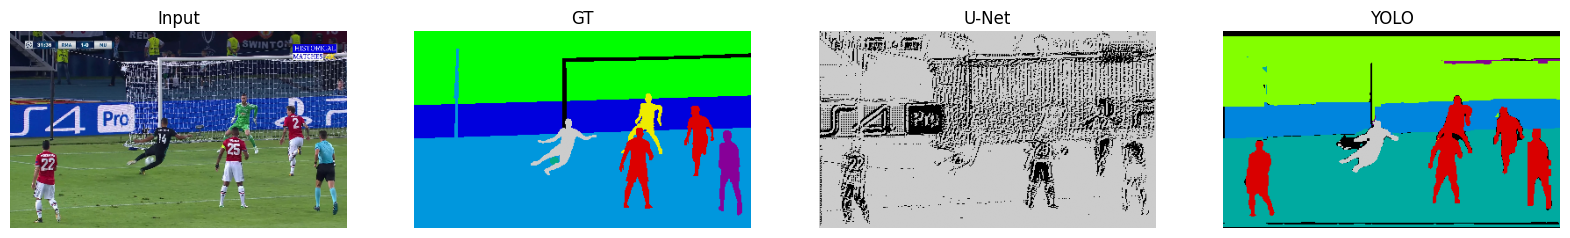

In [83]:
compare_models(unet_model,yolo_model,val_dataset,device, idx=0)